# End-to-End ETL & Data Analysis Pipeline: Superstore Sales

**Pipeline:** Raw Data → Extract → Explore → Clean → Transform → Analyze → Design DB → Load → SQL Reporting

| | |
|---|---|
| **Dataset** | Sample Superstore (US retail orders 2015-2018), ~300-row sample of the public dataset |
| **Domain** | E-commerce / Retail sales |
| **Tools** | Python, Pandas, Matplotlib/Seaborn, SQLAlchemy + PyMySQL, MySQL |
| **Reproducibility** | Run all cells top to bottom; the notebook (re)creates the database tables and reloads the data |

**Objective:** understand what drives sales and profit (categories, regions, customers, discounts, returns, shipping)
and build a clean, relational MySQL database that supports reporting.

> **Before running:** start MySQL (8.0+) and set `DB_USER`, `DB_PASSWORD`, `DB_HOST`, `DB_PORT` in the config cell
> (or as environment variables). The database `superstore_db` is created automatically.

## 0. Setup & configuration

In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")

# ---- file locations -------------------------------------------------------
RAW_FILE = "raw/superstore_raw.csv"
FIG_DIR  = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# ---- database connection (edit these, or set environment variables) -------
DB_USER     = os.getenv("DB_USER", "root")        # was "etl"
DB_PASSWORD = os.getenv("DB_PASSWORD", "admin") # was "etl_pass", use YOUR password
DB_HOST     = os.getenv("DB_HOST", "localhost")
DB_PORT     = int(os.getenv("DB_PORT", "3306"))
DB_NAME     = "superstore_db"

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=130, bbox_inches="tight")
    plt.show()

# running log of every data-quality issue found and how it was handled (used in the report)
quality_log = []
def log_issue(phase, issue, count, action):
    quality_log.append({"phase": phase, "issue": issue, "rows_or_values": count, "action": action})

## Phase 1: Data Acquisition & Extraction

The raw file `raw/superstore_raw.csv` is a ~300-row sample of the public *Sample Superstore* dataset
(source: <https://github.com/leonism/sample-superstore>; sampling script: `prepare_raw_sample.py`).
Whole orders were sampled so each order keeps all its line items.

The file keeps the **original messy layout** of the public CSV: after the order rows, two extra sheets are pasted
below in the same file, the *People* sheet (regional managers) and the *Returns* sheet (returned order IDs).
Extraction therefore has to locate those sections and split them into three raw DataFrames.

In [2]:
# Pass 1: read everything as text so we can locate the section boundaries safely
probe = pd.read_csv(RAW_FILE, dtype=str, keep_default_na=False)
i_people  = probe.index[probe["Row ID"] == "Person"][0]     # header row of the People sheet
i_returns = probe.index[probe["Row ID"] == "Returned"][0]   # header row of the Returns sheet
print(f"Orders section : rows 0 - {i_people - 1}")
print(f"People section : header at row {i_people}")
print(f"Returns section: header at row {i_returns}")

Orders section : rows 0 - 299
People section : header at row 300
Returns section: header at row 305


In [3]:
# Pass 2: extract each section into its own raw DataFrame (pandas infers the natural dtypes)
raw_orders  = pd.read_csv(RAW_FILE, nrows=i_people)
raw_people  = (probe.loc[i_people + 1 : i_returns - 1, ["Row ID", "Order ID"]]
                    .rename(columns={"Row ID": "Person", "Order ID": "Region"}).reset_index(drop=True))
raw_returns = (probe.loc[i_returns + 1 :, ["Row ID", "Order ID"]]
                    .rename(columns={"Row ID": "Returned"}).reset_index(drop=True))

# Preserve the untouched raw data: every later step works on copies
RAW_ORDERS_BACKUP, RAW_PEOPLE_BACKUP, RAW_RETURNS_BACKUP = raw_orders.copy(), raw_people.copy(), raw_returns.copy()

print("raw_orders :", raw_orders.shape)
print("raw_people :", raw_people.shape)
print("raw_returns:", raw_returns.shape)

raw_orders : (300, 21)
raw_people : (4, 2)
raw_returns: (34, 2)


## Phase 2: Exploratory Data Analysis (before cleaning)

### 2.1 Basic dataset exploration

In [4]:
print(f"Rows: {raw_orders.shape[0]}   Columns: {raw_orders.shape[1]}\n")
print("Column names:", list(raw_orders.columns), "\n")
raw_orders.info()

Rows: 300   Columns: 21

Column names: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'] 

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         300 non-null    int64  
 1   Order ID       300 non-null    str    
 2   Order Date     300 non-null    str    
 3   Ship Date      300 non-null    str    
 4   Ship Mode      300 non-null    str    
 5   Customer ID    300 non-null    str    
 6   Customer Name  300 non-null    str    
 7   Segment        300 non-null    str    
 8   Country        300 non-null    str    
 9   City           300 non-null    str    
 10  State          300 non-null    str    
 11  Postal Code    295 non-null 

In [5]:
raw_orders.head(8)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,48,CA-2017-169194,6/20/2017,6/25/2017,Standard Class,LH-16900,Lena Hernandez,Consumer,United States,Dover,Delaware,"19,901.00",East,TEC-AC-10002167,Technology,Accessories,Imation 8gb Micro Traveldrive Usb 2.0 Flash Drive,45.00,3,0.00,4.95
1,49,CA-2017-169194,6/20/2017,6/25/2017,Standard Class,LH-16900,Lena Hernandez,Consumer,United States,Dover,Delaware,"19,901.00",East,TEC-PH-10003988,Technology,Phones,"LF Elite 3D Dazzle Designer Hard Case Cover, L...",21.80,2,0.00,6.10
2,68,CA-2015-106376,12/5/2015,12/10/2015,Standard Class,BS-11590,Brendan Sweed,Corporate,United States,Gilbert,Arizona,"85,234.00",West,OFF-AR-10002671,Office Supplies,Art,Hunt BOSTON Model 1606 High-Volume Electric Pe...,"1,113.02",8,0.20,111.30
3,69,CA-2015-106376,12/5/2015,12/10/2015,Standard Class,BS-11590,Brendan Sweed,Corporate,United States,Gilbert,Arizona,"85,234.00",West,TEC-PH-10002726,Technology,Phones,netTALK DUO VoIP Telephone Service,167.97,4,0.20,62.99
4,134,CA-2017-145583,10/13/2017,10/19/2017,Standard Class,LC-16885,Lena Creighton,Consumer,United States,Roseville,California,"95,661.00",West,OFF-PA-10001804,Office Supplies,Paper,Xerox 195,20.04,3,0.00,9.62
5,135,CA-2017-145583,10/13/2017,10/19/2017,Standard Class,LC-16885,Lena Creighton,Consumer,United States,Roseville,California,"95,661.00",West,OFF-PA-10001736,Office Supplies,Paper,Xerox 1880,35.44,1,0.00,16.66
6,136,CA-2017-145583,10/13/2017,10/19/2017,Standard Class,LC-16885,Lena Creighton,Consumer,United States,Roseville,California,"95,661.00",West,OFF-AR-10001149,Office Supplies,Art,"Sanford Colorific Colored Pencils, 12/Box",11.52,4,0.00,3.46
7,137,CA-2017-145583,10/13/2017,10/19/2017,Standard Class,LC-16885,Lena Creighton,Consumer,United States,Roseville,California,"95,661.00",West,OFF-FA-10002988,Office Supplies,Fasteners,Ideal Clamps,4.02,2,0.00,1.97


In [6]:
raw_orders.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,300.00,"4,885.27","3,315.45",48.00,"1,792.50","4,456.50","8,446.25","9,993.00"
Postal Code,295.00,"58,861.11","32,270.35","1,852.00","28,540.00","62,301.00","90,049.00","98,115.00"
Sales,300.00,249.81,494.38,1.98,17.86,61.88,254.07,"3,610.85"
Quantity,300.00,3.65,2.18,1.00,2.00,3.00,5.00,14.00
Discount,300.00,0.14,0.20,0.00,0.00,0.00,0.20,0.80
Profit,300.00,32.77,276.35,"-3,701.89",2.70,10.53,33.36,"1,668.20"


In [7]:
# Unique values per column (key columns matter most)
uniq = raw_orders.nunique().rename("unique_values").to_frame()
uniq["pct_of_rows"] = (uniq["unique_values"] / len(raw_orders) * 100).round(1)
uniq

,unique_values,pct_of_rows
Row ID,300,100.00
Order ID,155,51.70
Order Date,143,47.70
Ship Date,145,48.30
Ship Mode,4,1.30
Customer ID,140,46.70
Customer Name,140,46.70
Segment,3,1.00
Country,1,0.30
City,75,25.00


In [8]:
for col in ["Ship Mode", "Segment", "Country", "Region", "Category", "Sub-Category"]:
    print(f"--- {col} ({raw_orders[col].nunique()} unique)")
    print(raw_orders[col].value_counts(dropna=False).to_string(), "\n")
print("People sheet:"); display(raw_people)
print("Returns sheet (first 8 rows):"); display(raw_returns.head(8))

--- Ship Mode (4 unique)
Ship Mode
Standard Class    177
First Class        59
Second Class       46
Same Day           18 

--- Segment (3 unique)
Segment
Consumer       180
Corporate       75
Home Office     45 

--- Country (1 unique)
Country
United States    300 

--- Region (4 unique)
Region
West       108
East        71
Central     71
South       50 

--- Category (3 unique)
Category
Office Supplies    167
Technology          72
Furniture           61 

--- Sub-Category (17 unique)
Sub-Category
Paper          43
Binders        36
Phones         33
Accessories    29
Furnishings    29
Storage        22
Art            17
Labels         14
Chairs         14
Appliances     13
Tables         12
Envelopes      11
Machines        7
Fasteners       6
Bookcases       6
Supplies        5
Copiers         3 

People sheet:


,Person,Region
0,Anna Andreadi,West
1,Chuck Magee,East
2,Kelly Williams,Central
3,Cassandra Brandow,South


Returns sheet (first 8 rows):


,Returned,Order ID
0,Yes,CA-2015-124688
1,Yes,CA-2015-124688
2,Yes,CA-2015-124688
3,Yes,CA-2015-169019
4,Yes,CA-2015-169019
5,Yes,CA-2015-169019
6,Yes,CA-2015-169019
7,Yes,CA-2015-169019


### 2.2 Data quality analysis

In [9]:
# Missing values
miss = raw_orders.isna().sum().rename("missing").to_frame()
miss["pct"] = (miss["missing"] / len(raw_orders) * 100).round(2)
print("Missing values in orders:"); display(miss[miss["missing"] > 0] if miss["missing"].sum() else "none")

# Duplicates
dup_orders  = raw_orders.drop(columns="Row ID").duplicated().sum()
dup_returns = raw_returns.duplicated().sum()
print(f"Duplicate order lines (ignoring Row ID): {dup_orders}")
print(f"Duplicate rows in Returns sheet        : {dup_returns} of {len(raw_returns)}")
print(f"Order IDs in Returns sheet: {raw_returns['Order ID'].nunique()} unique")

Missing values in orders:


,missing,pct
Postal Code,5,1.67


Duplicate order lines (ignoring Row ID): 0
Duplicate rows in Returns sheet        : 23 of 34
Order IDs in Returns sheet: 11 unique


In [10]:
# Incorrect data types: dates stored as text, postal code stored as a number
print(raw_orders[["Order Date", "Ship Date", "Postal Code", "Row ID"]].dtypes, "\n")

# Date format consistency (expected m/d/yyyy)
pattern = r"^\d{1,2}/\d{1,2}/\d{4}$"
bad_dates = (~raw_orders["Order Date"].astype(str).str.match(pattern)).sum() + (~raw_orders["Ship Date"].astype(str).str.match(pattern)).sum()
print("Date values not in m/d/yyyy format:", bad_dates)

# Postal codes: US ZIP codes are 5 digits (some start with 0, e.g. New Jersey / Connecticut)
pc = raw_orders["Postal Code"].dropna().astype(int).astype(str)
print("Postal codes shorter than 5 digits (leading zero lost):", (pc.str.len() < 5).sum())
print("Postal codes missing:", raw_orders["Postal Code"].isna().sum())

Order Date         str
Ship Date          str
Postal Code    float64
Row ID           int64
dtype: object 

Date values not in m/d/yyyy format: 0
Postal codes shorter than 5 digits (leading zero lost): 13
Postal codes missing: 5


In [11]:
# Invalid / inconsistent values
print("Sales <= 0           :", (raw_orders["Sales"] <= 0).sum())
print("Quantity <= 0        :", (raw_orders["Quantity"] <= 0).sum())
print("Discount outside 0-1 :", (~raw_orders["Discount"].between(0, 1)).sum())
od, sd = pd.to_datetime(raw_orders["Order Date"], format="%m/%d/%Y"), pd.to_datetime(raw_orders["Ship Date"], format="%m/%d/%Y")
print("Shipped before ordered:", (sd < od).sum())
print("Negative profit lines  :", (raw_orders["Profit"] < 0).sum(), f"({(raw_orders['Profit'] < 0).mean():.1%})")

# Whitespace / casing problems in text columns
txt = raw_orders.select_dtypes("object").columns.drop(["Order Date", "Ship Date"])
ws = {c: int((raw_orders[c] != raw_orders[c].str.strip()).sum()) for c in txt}
print("Text values with leading/trailing spaces:", {k: v for k, v in ws.items() if v} or "none")

# Hidden characters: non-breaking spaces (\xa0) look like spaces but break joins / grouping
nbsp = {c: int(raw_orders[c].str.contains("\xa0", regex=False).sum()) for c in txt}
print("Values containing non-breaking spaces:", {k: v for k, v in nbsp.items() if v} or "none")

# One ID should map to one name / one category
print("\nProduct IDs with more than one product name:",
      (raw_orders.groupby("Product ID")["Product Name"].nunique() > 1).sum())
print("Customer IDs with more than one name       :",
      (raw_orders.groupby("Customer ID")["Customer Name"].nunique() > 1).sum())
print("Order IDs with more than one customer      :",
      (raw_orders.groupby("Order ID")["Customer ID"].nunique() > 1).sum())
rep = raw_orders.duplicated(["Order ID", "Product ID"], keep=False).sum()
print("Order lines where the same product repeats within one order:", rep)

Sales <= 0           : 0
Quantity <= 0        : 0
Discount outside 0-1 : 0
Shipped before ordered: 0
Negative profit lines  : 43 (14.3%)
Text values with leading/trailing spaces: none
Values containing non-breaking spaces: {'Product Name': 6}

Product IDs with more than one product name: 1
Customer IDs with more than one name       : 0
Order IDs with more than one customer      : 0
Order lines where the same product repeats within one order: 0


,column,lower_fence,upper_fence,outliers
0,Sales,-336.44,608.37,35
1,Quantity,-2.50,9.50,5
2,Discount,-0.30,0.50,21
3,Profit,-43.30,79.36,57


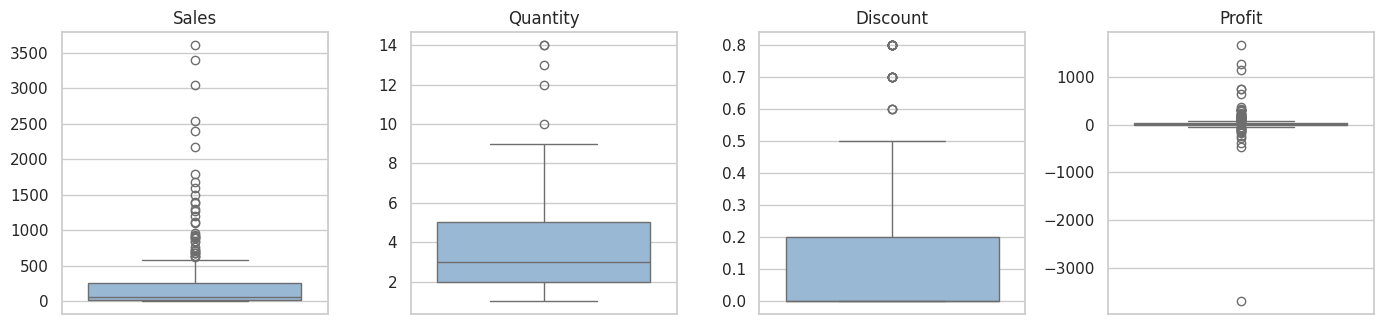

In [12]:
# Outliers (IQR rule: outside Q1 - 1.5*IQR .. Q3 + 1.5*IQR)
rows = []
for c in ["Sales", "Quantity", "Discount", "Profit"]:
    q1, q3 = raw_orders[c].quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    rows.append({"column": c, "lower_fence": lo, "upper_fence": hi,
                 "outliers": int(((raw_orders[c] < lo) | (raw_orders[c] > hi)).sum())})
display(pd.DataFrame(rows))

fig, ax = plt.subplots(1, 4, figsize=(14, 3.4))
for a, c in zip(ax, ["Sales", "Quantity", "Discount", "Profit"]):
    sns.boxplot(y=raw_orders[c], ax=a, color="#8fb8de"); a.set_title(c); a.set_ylabel("")
savefig("eda_outlier_boxplots")

**EDA data-quality findings** (each one is handled in Phase 3):

1. The file mixes **three sheets** in one CSV (orders, regional managers, returns).
2. **Dates are text** (`m/d/yyyy`) and **Postal Code is numeric**, so leading zeros are lost.
3. The Returns sheet contains **duplicate order IDs** (one row per returned line item).
4. Some **Product IDs map to more than one product name**.
5. **Heavy outliers** in `Sales` and `Profit` (large orders / big losses).
6. Column names contain spaces and hyphens, which is unfriendly for SQL.
7. **Non-breaking spaces** (`\xa0`) hidden inside some product names.
8. A handful of **missing postal codes**.
9. The numeric core is valid: no non-positive sales/quantities, no invalid discounts, no shipping-before-order dates.

### 2.3 Exploratory analysis

In [13]:
eda = raw_orders.copy()
eda["Order Date"] = pd.to_datetime(eda["Order Date"], format="%m/%d/%Y")
eda["Year"], eda["Month"] = eda["Order Date"].dt.year, eda["Order Date"].dt.to_period("M")

print("Sales by category"); display(eda.groupby("Category").agg(sales=("Sales","sum"), profit=("Profit","sum"), lines=("Row ID","count")).sort_values("sales", ascending=False))
print("Customers by region"); display(eda.groupby("Region")["Customer ID"].nunique().sort_values(ascending=False).rename("unique_customers").to_frame())
print("Average order value:", round(eda.groupby("Order ID")["Sales"].sum().mean(), 2))
print("Most popular sub-categories (units sold)"); display(eda.groupby("Sub-Category")["Quantity"].sum().sort_values(ascending=False).head(5).to_frame())
print("Least popular sub-categories (units sold)"); display(eda.groupby("Sub-Category")["Quantity"].sum().sort_values().head(5).to_frame())

Sales by category


,sales,profit,lines
Category,,,
Technology,"30,300.49","7,332.53",72
Furniture,"22,593.75","1,199.75",61
Office Supplies,"22,048.72","1,297.66",167


Customers by region


,unique_customers
Region,
West,49
Central,40
East,37
South,23


Average order value: 483.5
Most popular sub-categories (units sold)


,Quantity
Sub-Category,
Paper,163
Binders,142
Furnishings,121
Accessories,109
Phones,103


Least popular sub-categories (units sold)


,Quantity
Sub-Category,
Supplies,14
Copiers,15
Fasteners,18
Bookcases,26
Machines,30


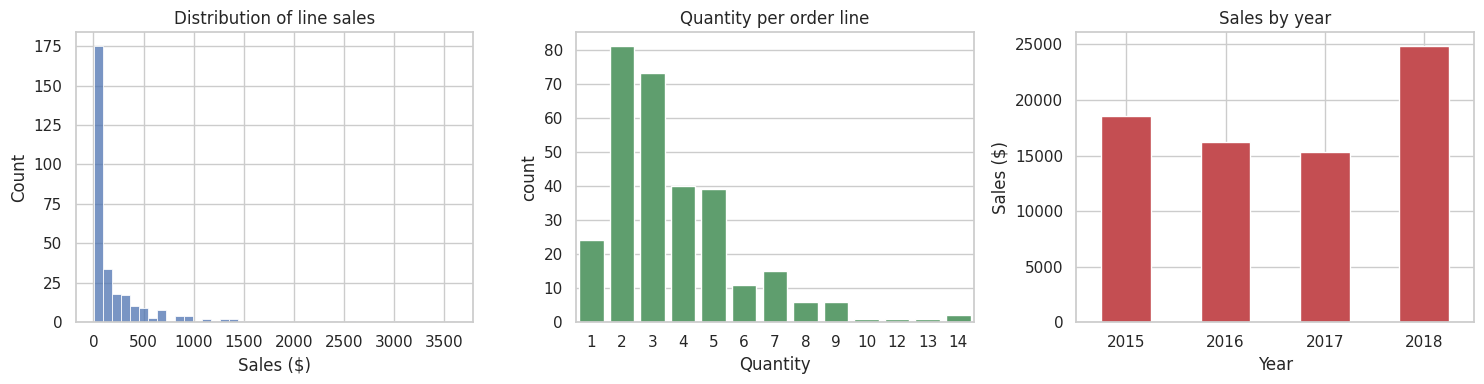

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(eda["Sales"], bins=40, ax=ax[0], color="#4c72b0"); ax[0].set_title("Distribution of line sales"); ax[0].set_xlabel("Sales ($)")
sns.countplot(data=eda, x="Quantity", ax=ax[1], color="#55a868"); ax[1].set_title("Quantity per order line")
eda.groupby("Year")["Sales"].sum().plot(kind="bar", ax=ax[2], color="#c44e52"); ax[2].set_title("Sales by year"); ax[2].set_ylabel("Sales ($)"); ax[2].tick_params(axis="x", rotation=0)
savefig("eda_distributions")

## Phase 3: Data Cleaning & Transformation

Every step below responds to a problem found during EDA. Each step records what was changed in `quality_log`.

### 3.1 Cleaning: orders

In [15]:
df = raw_orders.copy()

# 1) Rename columns -> snake_case (SQL-friendly, consistent)
df.columns = [re.sub(r"[^0-9a-zA-Z]+", "_", c).strip("_").lower() for c in df.columns]
log_issue("Clean", "Column names had spaces/hyphens", len(df.columns), "Renamed to snake_case")

# 2) Standardise text: trim, and collapse repeated whitespace (Python's \s also matches non-breaking spaces)
text_cols = df.select_dtypes("object").columns.drop(["order_date", "ship_date"])
n_nbsp = int(sum(df[c].str.contains("\xa0", regex=False).sum() for c in text_cols))   # count BEFORE fixing
for c in text_cols:
    df[c] = df[c].str.strip().str.replace(r"\s+", " ", regex=True)
log_issue("Clean", "Non-breaking spaces / stray whitespace in text", n_nbsp, "Replaced with normal spaces, trimmed, collapsed")

# 3) Correct data types
df["order_date"] = pd.to_datetime(df["order_date"], format="%m/%d/%Y")
df["ship_date"]  = pd.to_datetime(df["ship_date"],  format="%m/%d/%Y")
df["row_id"]     = df["row_id"].astype(int)
df["quantity"]   = df["quantity"].astype(int)
# postal code -> zero-padded 5-char string (restores leading zeros lost by numeric storage)
df["postal_code"] = df["postal_code"].astype("Int64").astype("string").str.zfill(5)
n_short = int((raw_orders["Postal Code"].dropna().astype(int).astype(str).str.len() < 5).sum())
log_issue("Clean", "Dates stored as text", len(df) * 2, "Converted to datetime64")
log_issue("Clean", "Postal code numeric (leading zeros lost)", n_short, "Converted to zero-padded 5-char string")

In [16]:
# 4) Missing values: fill postal code from other rows with the same city+state; leave NULL if impossible
missing_before = int(df["postal_code"].isna().sum())
fill = df.dropna(subset=["postal_code"]).groupby(["city", "state"])["postal_code"].agg(lambda s: s.mode().iloc[0])
mask = df["postal_code"].isna()
df.loc[mask, "postal_code"] = [fill.get((c, s), pd.NA) for c, s in zip(df.loc[mask, "city"], df.loc[mask, "state"])]
after_internal = int(df["postal_code"].isna().sum())

# Still missing? Use a small external reference (USPS): Burlington, Vermont -> 05401
external_zip = {("Burlington", "Vermont"): "05401"}
mask = df["postal_code"].isna()
df.loc[mask, "postal_code"] = [external_zip.get((c, s), pd.NA) for c, s in zip(df.loc[mask, "city"], df.loc[mask, "state"])]
log_issue("Clean", "Missing postal codes", missing_before,
          f"{missing_before - after_internal} filled from same city/state; {after_internal - int(df['postal_code'].isna().sum())} filled from external USPS reference; {int(df['postal_code'].isna().sum())} left NULL")
print("Missing postal codes: before", missing_before, "| after internal fill", after_internal, "| final", int(df["postal_code"].isna().sum()))
print("Remaining nulls in any other column:", int(df.drop(columns="postal_code").isna().sum().sum()))

# 5) Duplicate order lines (identical in every column except the surrogate row_id)
before = len(df)
df = df.drop_duplicates(subset=df.columns.drop("row_id"), keep="first")
log_issue("Clean", "Duplicate order lines", before - len(df), "Dropped (kept first)" if before - len(df) else "None found")
print("Duplicate order lines removed:", before - len(df))

Missing postal codes: before 5 | after internal fill 5 | final 0
Remaining nulls in any other column: 0
Duplicate order lines removed: 0


In [17]:
# 6) Invalid values: remove rows violating business rules
rules = {
    "sales <= 0":               df["sales"] <= 0,
    "quantity <= 0":            df["quantity"] <= 0,
    "discount outside 0-1":     ~df["discount"].between(0, 1),
    "shipped before ordered":   df["ship_date"] < df["order_date"],
}
bad = pd.concat(rules, axis=1).any(axis=1)
for name, m in rules.items(): print(f"{name:26s}: {int(m.sum())}")
log_issue("Clean", "Rows violating business rules", int(bad.sum()), "Removed" if bad.any() else "None found, validated OK")
df = df[~bad].copy()

# 7) Unexpected categories: validate against the allowed sets
allowed = {"ship_mode": {"Same Day", "First Class", "Second Class", "Standard Class"},
           "segment":   {"Consumer", "Corporate", "Home Office"},
           "category":  {"Furniture", "Office Supplies", "Technology"},
           "region":    {"East", "West", "Central", "South"}}
for c, ok in allowed.items():
    unexpected = set(df[c].unique()) - ok
    assert not unexpected, f"{c}: unexpected values {unexpected}"
print("All category columns contain only expected values")

# 8) Inconsistent product names: one product_id must have ONE name (keep the most frequent, else first seen)
names = df.groupby("product_id")["product_name"].agg(lambda s: s.value_counts().index[0] if s.value_counts().iloc[0] > 1 else s.iloc[0])
n_conf = int((df.groupby("product_id")["product_name"].nunique() > 1).sum())
df["product_name"] = df["product_id"].map(names)
log_issue("Clean", "Product IDs with several names", n_conf, "Standardised to one canonical name per product_id")
print("Product IDs with conflicting names fixed:", n_conf)

# 9) Outliers: flag (do NOT delete): large sales/losses are real business events, not errors
q1, q3 = df["profit"].quantile([.25, .75]); iqr = q3 - q1
df["is_profit_outlier"] = (df["profit"] < q1 - 1.5 * iqr) | (df["profit"] > q3 + 1.5 * iqr)
log_issue("Clean", "Profit/sales outliers (IQR)", int(df["is_profit_outlier"].sum()), "Flagged and kept (valid business events)")

# 10) Remove unnecessary columns: country is a single constant value
const = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns:", const)

sales <= 0                : 0
quantity <= 0             : 0
discount outside 0-1      : 0
shipped before ordered    : 0
All category columns contain only expected values
Product IDs with conflicting names fixed: 1
Constant columns: ['country']


### 3.2 Cleaning: returns & regional managers

In [18]:
# Returns sheet: one row per returned LINE ITEM -> collapse to one row per returned order
ret_before = len(raw_returns)
returns_clean = (raw_returns[["Order ID"]].rename(columns={"Order ID": "order_id"})
                 .assign(order_id=lambda d: d["order_id"].str.strip()).drop_duplicates().reset_index(drop=True))
orphans = ~returns_clean["order_id"].isin(df["order_id"])
returns_clean = returns_clean[~orphans]
log_issue("Clean", "Returns sheet: duplicate order IDs", ret_before - len(raw_returns.drop_duplicates()), "Collapsed to one row per returned order")
log_issue("Clean", "Returned orders missing from orders table", int(orphans.sum()), "Removed (would break the foreign key)" if orphans.any() else "None, all returns match an order")
print(f"Returns: {ret_before} rows -> {len(returns_clean)} unique returned orders (orphans removed: {int(orphans.sum())})")

# Regional managers
people_clean = raw_people.apply(lambda s: s.str.strip())
people_clean.columns = ["manager_name", "region_name"]
people_clean

Returns: 34 rows -> 11 unique returned orders (orphans removed: 0)


,manager_name,region_name
0,Anna Andreadi,West
1,Chuck Magee,East
2,Kelly Williams,Central
3,Cassandra Brandow,South


### 3.3 Transformation: derived columns and splitting into entity DataFrames

Derived columns support analysis and segmentation:

| New column | Why |
|---|---|
| `order_year`, `order_month`, `order_month_name`, `year_month` | Time-based trend analysis |
| `ship_days` | Shipping performance |
| `unit_list_price` = sales / (quantity × (1 − discount)) | Recovers the pre-discount price per unit, used for `products.avg_list_price` |
| `profit_margin` = profit / sales | Compare profitability across groups |
| `discount_band` | Group continuous discount into business-friendly bands |
| `is_returned` | Flag orders that appear in the Returns sheet |
| `customer_tier` (Gold/Silver/Bronze) | Customer segmentation by total revenue (top / middle / bottom third) |

In [19]:
df["order_year"]       = df["order_date"].dt.year
df["order_month"]      = df["order_date"].dt.month
df["order_month_name"] = df["order_date"].dt.strftime("%b")
df["year_month"]       = df["order_date"].dt.strftime("%Y-%m")
df["ship_days"]        = (df["ship_date"] - df["order_date"]).dt.days
df["unit_list_price"]  = df["sales"] / (df["quantity"] * (1 - df["discount"]))
df["profit_margin"]    = df["profit"] / df["sales"]
df["discount_band"]    = pd.cut(df["discount"], bins=[-0.01, 0, 0.2, 0.4, 1.0],
                                labels=["No discount", "Low (1-20%)", "Medium (21-40%)", "High (>40%)"])
df["is_returned"]      = df["order_id"].isin(returns_clean["order_id"])

# Customer segmentation by lifetime revenue (rank first so ties never break the tercile split)
cust_rev = df.groupby("customer_id")["sales"].sum()
tier = pd.qcut(cust_rev.rank(method="first"), 3, labels=["Bronze", "Silver", "Gold"])
df["customer_tier"] = df["customer_id"].map(tier).astype(str)

print("Clean analytical table:", df.shape)
df.head()

Clean analytical table: (300, 32)


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,is_profit_outlier,order_year,order_month,order_month_name,year_month,ship_days,unit_list_price,profit_margin,discount_band,is_returned,customer_tier
0,48,CA-2017-169194,2017-06-20,2017-06-25,Standard Class,LH-16900,Lena Hernandez,Consumer,United States,Dover,Delaware,19901,East,TEC-AC-10002167,Technology,Accessories,Imation 8gb Micro Traveldrive Usb 2.0 Flash Drive,45.00,3,0.00,4.95,False,2017,6,Jun,2017-06,5,15.00,0.11,No discount,False,Bronze
1,49,CA-2017-169194,2017-06-20,2017-06-25,Standard Class,LH-16900,Lena Hernandez,Consumer,United States,Dover,Delaware,19901,East,TEC-PH-10003988,Technology,Phones,"LF Elite 3D Dazzle Designer Hard Case Cover, L...",21.80,2,0.00,6.10,False,2017,6,Jun,2017-06,5,10.90,0.28,No discount,False,Bronze
2,68,CA-2015-106376,2015-12-05,2015-12-10,Standard Class,BS-11590,Brendan Sweed,Corporate,United States,Gilbert,Arizona,85234,West,OFF-AR-10002671,Office Supplies,Art,Hunt BOSTON Model 1606 High-Volume Electric Pe...,"1,113.02",8,0.20,111.30,True,2015,12,Dec,2015-12,5,173.91,0.10,Low (1-20%),False,Gold
3,69,CA-2015-106376,2015-12-05,2015-12-10,Standard Class,BS-11590,Brendan Sweed,Corporate,United States,Gilbert,Arizona,85234,West,TEC-PH-10002726,Technology,Phones,netTALK DUO VoIP Telephone Service,167.97,4,0.20,62.99,False,2015,12,Dec,2015-12,5,52.49,0.38,Low (1-20%),False,Gold
4,134,CA-2017-145583,2017-10-13,2017-10-19,Standard Class,LC-16885,Lena Creighton,Consumer,United States,Roseville,California,95661,West,OFF-PA-10001804,Office Supplies,Paper,Xerox 195,20.04,3,0.00,9.62,False,2017,10,Oct,2017-10,6,6.68,0.48,No discount,True,Gold


In [20]:
# ---- Split into entity DataFrames (these become the database tables) ----
regions = (people_clean.sort_values("region_name").reset_index(drop=True)
           .assign(region_id=lambda d: d.index + 1)[["region_id", "region_name", "manager_name"]])

loc_cols = ["city", "state", "postal_code", "country", "region"]
locations = (df[loc_cols].drop_duplicates().sort_values(["state", "city", "postal_code"]).reset_index(drop=True)
             .assign(location_id=lambda d: d.index + 1)
             .merge(regions[["region_id", "region_name"]], left_on="region", right_on="region_name", how="left"))
locations = locations[["location_id", "city", "state", "postal_code", "country", "region_id"]]

customers = (df.sort_values("row_id").drop_duplicates("customer_id")
             [["customer_id", "customer_name", "segment", "customer_tier"]].reset_index(drop=True))

products = (df.groupby("product_id")
            .agg(product_name=("product_name", "first"), category=("category", "first"),
                 sub_category=("sub_category", "first"), avg_list_price=("unit_list_price", "median"))
            .round(2).reset_index())

orders = (df.sort_values("row_id").drop_duplicates("order_id")
          .merge(locations[["location_id", "city", "state", "postal_code", "country"]],
                 on=["city", "state", "postal_code", "country"], how="left")
          [["order_id", "customer_id", "location_id", "order_date", "ship_date", "ship_mode"]].reset_index(drop=True))

order_details = (df[["row_id", "order_id", "product_id", "quantity", "discount", "sales", "profit"]]
                 .rename(columns={"row_id": "order_detail_id"}).reset_index(drop=True))
order_returns = returns_clean.copy()

tables = {"regions": regions, "locations": locations, "customers": customers, "products": products,
          "orders": orders, "order_details": order_details, "order_returns": order_returns}
pd.DataFrame({"table": tables.keys(), "rows": [len(t) for t in tables.values()], "columns": [t.shape[1] for t in tables.values()]})

,table,rows,columns
0,regions,4,3
1,locations,102,6
2,customers,140,4
3,products,280,5
4,orders,155,6
5,order_details,300,7
6,order_returns,11,1


In [21]:
# Integrity checks BEFORE touching the database
assert regions["region_id"].is_unique and locations["location_id"].is_unique
assert customers["customer_id"].is_unique and products["product_id"].is_unique and orders["order_id"].is_unique
assert order_details["order_detail_id"].is_unique
assert locations["region_id"].notna().all(),                       "location without a region"
assert orders["location_id"].notna().all(),                        "order without a location"
assert orders["customer_id"].isin(customers["customer_id"]).all(), "order with unknown customer"
assert order_details["order_id"].isin(orders["order_id"]).all(),   "detail with unknown order"
assert order_details["product_id"].isin(products["product_id"]).all(), "detail with unknown product"
assert order_returns["order_id"].isin(orders["order_id"]).all(),   "return with unknown order"
print("All primary/foreign key checks passed in Pandas")

All primary/foreign key checks passed in Pandas


## Phase 4: Data Analysis & Insights (Pandas)

Business questions:

1. Which product categories generate the most revenue and profit?
2. How do sales trend over time, and which months are strongest?
3. Which region sells the most and which is the most profitable?
4. Which customers contribute the most revenue, and how concentrated is it?
5. How do discounts affect profitability?
6. Which sub-categories lose money?
7. What is the average order value by segment?
8. What share of orders is returned?

,sales,profit,orders,units,sales_share_pct,profit_margin_pct
category,,,,,,
Technology,"30,300.49","7,332.53",58,257,40.43,24.20
Furniture,"22,593.75","1,199.75",49,246,30.15,5.31
Office Supplies,"22,048.72","1,297.66",107,593,29.42,5.89


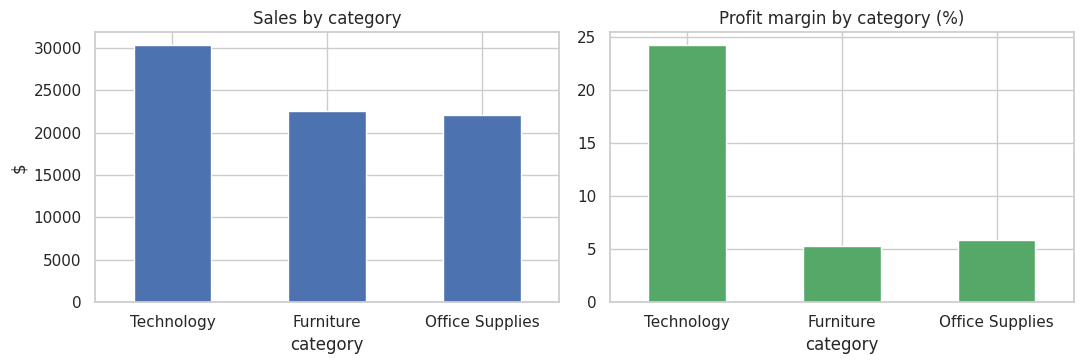

In [22]:
# Q1: category performance
cat = df.groupby("category").agg(sales=("sales","sum"), profit=("profit","sum"), orders=("order_id","nunique"), units=("quantity","sum"))
cat["sales_share_pct"]  = cat["sales"] / cat["sales"].sum() * 100
cat["profit_margin_pct"] = cat["profit"] / cat["sales"] * 100
cat = cat.sort_values("sales", ascending=False)
display(cat)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
cat["sales"].plot(kind="bar", ax=ax[0], color="#4c72b0"); ax[0].set_title("Sales by category"); ax[0].set_ylabel("$"); ax[0].tick_params(axis="x", rotation=0)
cat["profit_margin_pct"].plot(kind="bar", ax=ax[1], color="#55a868"); ax[1].set_title("Profit margin by category (%)"); ax[1].tick_params(axis="x", rotation=0)
savefig("q1_category")

,sales,growth_pct
order_year,,
2015,"18,573.34",NaN
2016,"16,193.17",-12.81
2017,"15,325.78",-5.36
2018,"24,850.68",62.15


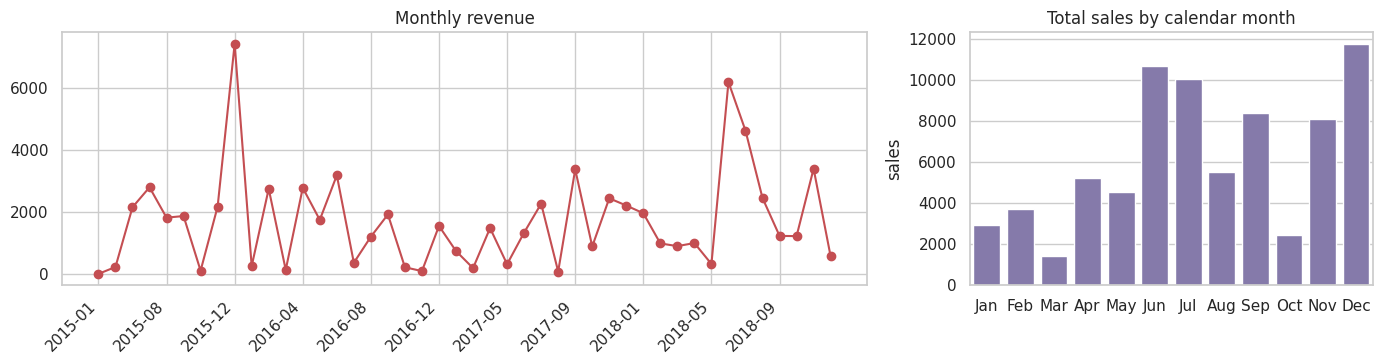

In [23]:
# Q2: time trend
monthly = df.groupby("year_month").agg(revenue=("sales","sum"), orders=("order_id","nunique"))
yearly  = df.groupby("order_year")["sales"].sum()
by_moy  = df.groupby(["order_month", "order_month_name"])["sales"].sum().reset_index().sort_values("order_month")
display(yearly.rename("sales").to_frame().assign(growth_pct=lambda d: d["sales"].pct_change() * 100))

fig, ax = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={"width_ratios": [2, 1]})
ax[0].plot(monthly.index, monthly["revenue"], marker="o", color="#c44e52"); ax[0].set_title("Monthly revenue")
ax[0].set_xticks(range(0, len(monthly), 4)); ax[0].set_xticklabels(monthly.index[::4], rotation=45, ha="right")
sns.barplot(data=by_moy, x="order_month_name", y="sales", ax=ax[1], color="#8172b2"); ax[1].set_title("Total sales by calendar month"); ax[1].set_xlabel("")
savefig("q2_trend")

,sales,profit,customers,orders,profit_margin_pct
region,,,,,
West,"28,159.75","5,270.76",49,53,18.72
East,"25,471.02","6,409.04",37,38,25.16
Central,"12,752.24","-4,205.83",40,40,-32.98
South,"8,559.95","2,355.98",23,24,27.52


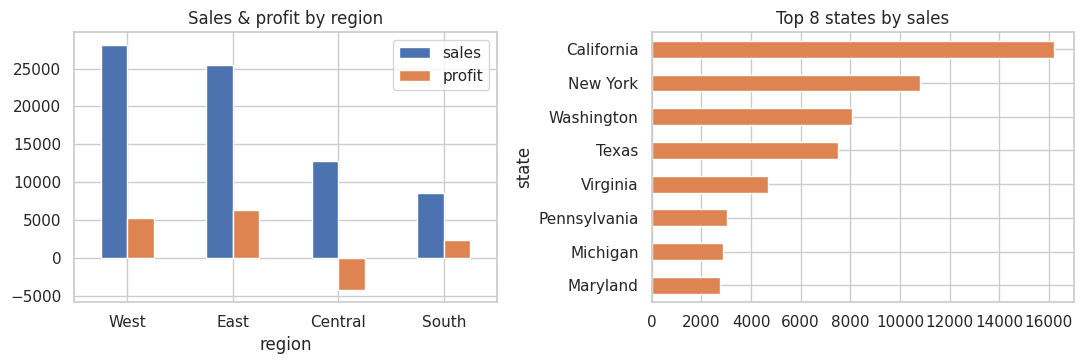

In [24]:
# Q3: region performance
reg = df.groupby("region").agg(sales=("sales","sum"), profit=("profit","sum"), customers=("customer_id","nunique"), orders=("order_id","nunique"))
reg["profit_margin_pct"] = reg["profit"] / reg["sales"] * 100
reg = reg.sort_values("sales", ascending=False); display(reg)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
reg[["sales", "profit"]].plot(kind="bar", ax=ax[0]); ax[0].set_title("Sales & profit by region"); ax[0].tick_params(axis="x", rotation=0)
state = df.groupby("state")["sales"].sum().sort_values(ascending=False).head(8)
state.sort_values().plot(kind="barh", ax=ax[1], color="#dd8452"); ax[1].set_title("Top 8 states by sales")
savefig("q3_region")

In [25]:
# Q4: customers
cust = df.groupby(["customer_id", "customer_name"]).agg(revenue=("sales","sum"), profit=("profit","sum"), orders=("order_id","nunique")).sort_values("revenue", ascending=False).reset_index()
display(cust.head(10))
top10_share  = cust["revenue"].head(10).sum() / cust["revenue"].sum() * 100
top20pct_cnt = max(1, int(round(len(cust) * 0.2)))
top20_share  = cust["revenue"].head(top20pct_cnt).sum() / cust["revenue"].sum() * 100
print(f"Top 10 customers = {top10_share:.1f}% of revenue;  top 20% of customers ({top20pct_cnt}) = {top20_share:.1f}% of revenue")
tier_rev = df.groupby("customer_tier")["sales"].sum().reindex(["Gold","Silver","Bronze"]); display((tier_rev / tier_rev.sum() * 100).round(1).rename("share_of_revenue_pct").to_frame())

,customer_id,customer_name,revenue,profit,orders
0,NP-18700,Nora Preis,"4,630.51",242.99,1
1,JK-15640,Jim Kriz,"4,177.38",988.67,3
2,SR-20740,Steven Roelle,"3,567.42","1,669.38",2
3,LC-16885,Lena Creighton,"3,457.64","1,275.96",3
4,GT-14710,Greg Tran,"2,670.19",974.31,1
5,LF-17185,Luke Foster,"2,656.72","-3,791.16",1
6,PW-19240,Pierre Wener,"2,541.98","1,270.99",1
7,HW-14935,Helen Wasserman,"2,340.06",595.74,1
8,CC-12610,Corey Catlett,"1,812.01",481.44,1
9,KT-16480,Kean Thornton,"1,799.97",240.00,1


Top 10 customers = 39.6% of revenue;  top 20% of customers (28) = 69.3% of revenue


,share_of_revenue_pct
customer_tier,
Gold,86.20
Silver,11.60
Bronze,2.20


,lines,sales,profit,profit_margin_pct
discount_band,,,,
No discount,153,"34,783.53","11,383.33",32.73
Low (1-20%),110,"29,093.72","4,586.19",15.76
Medium (21-40%),15,"7,325.44",-753.62,-10.29
High (>40%),22,"3,740.28","-5,385.96",-144.00


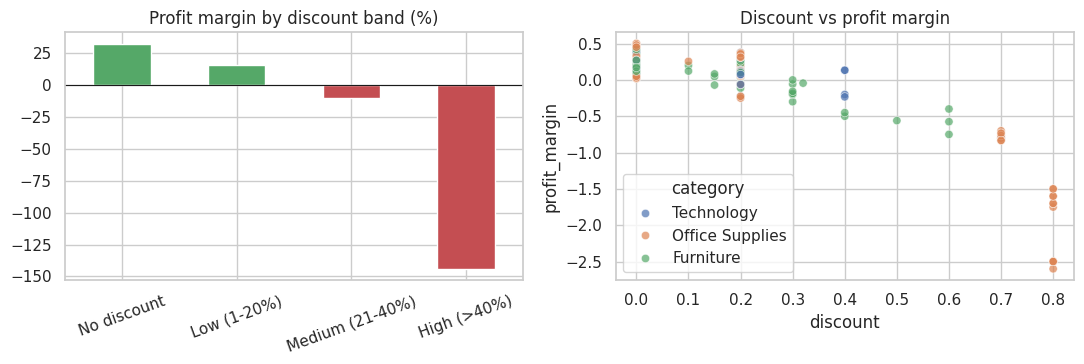

Correlation (discount vs profit margin): -0.856


In [26]:
# Q5: discounts vs profitability
disc = df.groupby("discount_band").agg(lines=("row_id","count"), sales=("sales","sum"), profit=("profit","sum"))
disc["profit_margin_pct"] = disc["profit"] / disc["sales"] * 100
display(disc)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
disc["profit_margin_pct"].plot(kind="bar", ax=ax[0], color=["#55a868" if v >= 0 else "#c44e52" for v in disc["profit_margin_pct"]]); ax[0].axhline(0, color="k", lw=.8)
ax[0].set_title("Profit margin by discount band (%)"); ax[0].set_xlabel(""); ax[0].tick_params(axis="x", rotation=20)
sns.scatterplot(data=df, x="discount", y="profit_margin", hue="category", ax=ax[1], alpha=.7); ax[1].set_title("Discount vs profit margin")
savefig("q5_discount")
print("Correlation (discount vs profit margin):", round(df["discount"].corr(df["profit_margin"]), 3))

,category,sub_category,sales,profit,margin_pct
6,Office Supplies,Binders,"10,825.04",-528.18,-4.88
3,Furniture,Tables,"9,223.04",-334.19,-3.62
4,Office Supplies,Appliances,"2,659.20",-40.79,-1.53
8,Office Supplies,Fasteners,58.01,23.17,39.94
12,Office Supplies,Supplies,101.64,24.31,23.92
9,Office Supplies,Labels,222.51,100.08,44.98


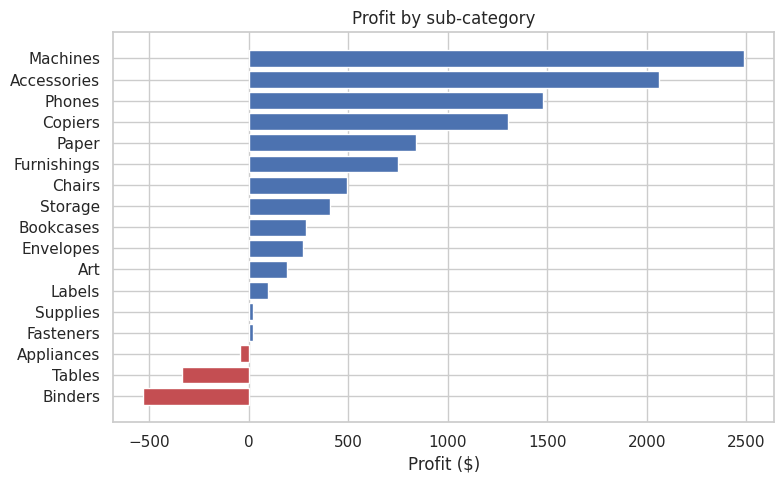

In [27]:
# Q6: sub-category profitability
sub = df.groupby(["category", "sub_category"]).agg(sales=("sales","sum"), profit=("profit","sum")).reset_index()
sub["margin_pct"] = sub["profit"] / sub["sales"] * 100
sub = sub.sort_values("profit")
display(sub.head(6))
plt.figure(figsize=(8, 5))
plt.barh(sub["sub_category"], sub["profit"], color=["#c44e52" if p < 0 else "#4c72b0" for p in sub["profit"]])
plt.title("Profit by sub-category"); plt.xlabel("Profit ($)")
savefig("q6_subcategory")

In [28]:
# Q7: average order value by segment  |  Q8: returns
order_tot = df.groupby("order_id").agg(order_value=("sales","sum"), segment=("segment","first"), category_mix=("category","nunique"), returned=("is_returned","first"))
aov = order_tot.groupby("segment")["order_value"].agg(orders="count", avg_order_value="mean", median_order_value="median").sort_values("avg_order_value", ascending=False)
display(aov)
overall_aov = order_tot["order_value"].mean()
return_rate = order_tot["returned"].mean() * 100
ret_cat = df.groupby("category").apply(lambda g: g.loc[g["is_returned"], "order_id"].nunique() / g["order_id"].nunique() * 100).sort_values(ascending=False)
print(f"Overall average order value: ${overall_aov:,.2f}")
print(f"Orders returned: {int(order_tot['returned'].sum())} of {len(order_tot)} ({return_rate:.1f}%)")
display(ret_cat.round(1).rename("return_rate_pct").to_frame())

,orders,avg_order_value,median_order_value
segment,,,
Home Office,25,578.37,184.66
Corporate,33,577.52,272.23
Consumer,97,427.07,98.16


Overall average order value: $483.50
Orders returned: 11 of 155 (7.1%)


,return_rate_pct
category,
Furniture,14.30
Technology,10.30
Office Supplies,8.40


### Key insights (computed directly from the cleaned data)

In [29]:
best_cat, worst_cat = cat.index[0], cat["profit_margin_pct"].idxmin()
best_reg, top_margin_reg = reg.index[0], reg["profit_margin_pct"].idxmax()
low_margin_reg = reg["profit_margin_pct"].idxmin()
peak_month = by_moy.loc[by_moy["sales"].idxmax(), "order_month_name"]
q4_share = by_moy[by_moy["order_month"].isin([9, 10, 11, 12])]["sales"].sum() / by_moy["sales"].sum() * 100
loss_sub = sub[sub["profit"] < 0]
hi = disc.loc["High (>40%)"] if "High (>40%)" in disc.index else None
nodisc = disc.loc["No discount"]

insights = [
 f"{best_cat} is the top category: ${cat.loc[best_cat,'sales']:,.0f} in sales, {cat.loc[best_cat,'sales_share_pct']:.1f}% of total revenue.",
 f"{cat['profit_margin_pct'].idxmax()} has the best margin ({cat['profit_margin_pct'].max():.1f}%) while {worst_cat} has the lowest ({cat['profit_margin_pct'].min():.1f}%).",
 f"The {best_reg} region leads in sales (${reg.loc[best_reg,'sales']:,.0f}), but {top_margin_reg} is the most profitable per dollar ({reg.loc[top_margin_reg,'profit_margin_pct']:.1f}% margin vs {reg.loc[low_margin_reg,'profit_margin_pct']:.1f}% in {low_margin_reg}).",
 f"Discounts hurt profit: orders with no discount earn a {nodisc['profit_margin_pct']:.1f}% margin" + (f", but lines discounted over 40% run at {hi['profit_margin_pct']:.1f}%." if hi is not None else "."),
 f"Sales are seasonal: Sep-Dec accounts for {q4_share:.0f}% of total sales (vs 33% if evenly spread), and {peak_month} is the single strongest month.",
 f"Revenue is concentrated in a few customers: the top 10 customers contribute {top10_share:.1f}% of revenue and the top 20% of customers contribute {top20_share:.1f}%.",
 (f"{len(loss_sub)} sub-categories lose money overall (worst: {loss_sub.iloc[0]['sub_category']}, a loss of ${abs(loss_sub.iloc[0]['profit']):,.0f})." if len(loss_sub) else "Every sub-category is profitable overall, although individual lines still lose money."),
 f"The average order is worth ${overall_aov:,.2f}; {aov.index[0]} customers spend the most per order (${aov.iloc[0]['avg_order_value']:,.2f}).",
 f"{return_rate:.1f}% of orders were returned; {ret_cat.index[0]} has the highest return rate ({ret_cat.iloc[0]:.1f}%).",
]
for i, s in enumerate(insights, 1): print(f"{i}. {s}\n")

1. Technology is the top category: $30,300 in sales, 40.4% of total revenue.

2. Technology has the best margin (24.2%) while Furniture has the lowest (5.3%).

3. The West region leads in sales ($28,160), but South is the most profitable per dollar (27.5% margin vs -33.0% in Central).

4. Discounts hurt profit: orders with no discount earn a 32.7% margin, but lines discounted over 40% run at -144.0%.

5. Sales are seasonal: Sep-Dec accounts for 41% of total sales (vs 33% if evenly spread), and Dec is the single strongest month.

6. Revenue is concentrated in a few customers: the top 10 customers contribute 39.6% of revenue and the top 20% of customers contribute 69.3%.

7. 3 sub-categories lose money overall (worst: Binders, a loss of $528).

8. The average order is worth $483.50; Home Office customers spend the most per order ($578.37).

9. 7.1% of orders were returned; Furniture has the highest return rate (14.3%).



## Phase 5: Database Design (MySQL)

The flat Superstore file mixes customer, product, location and order attributes in every row. It is normalised into **7 related tables**:

| Table | Grain | Primary key | Foreign keys |
|---|---|---|---|
| `regions` | one row per sales region (+ its manager) | `region_id` | |
| `locations` | one row per city / state / postal code | `location_id` | `region_id` → regions |
| `customers` | one row per customer | `customer_id` | |
| `products` | one row per product | `product_id` | |
| `orders` | one row per order | `order_id` | `customer_id` → customers, `location_id` → locations |
| `order_details` | one row per order line item | `order_detail_id` | `order_id` → orders, `product_id` → products |
| `order_returns` | one row per returned order | `order_id` | `order_id` → orders |

**Constraints:** `CHECK` constraints enforce valid quantity, discount (0-1), sales, ship date ≥ order date and allowed
segment / ship-mode values. `UNIQUE` constraints on `region_name` and on `(city, state, postal_code)`.
The ERD is in `ERD.png`.

In [30]:
DDL = """
SET FOREIGN_KEY_CHECKS = 0;
DROP TABLE IF EXISTS order_returns;
DROP TABLE IF EXISTS order_details;
DROP TABLE IF EXISTS orders;
DROP TABLE IF EXISTS products;
DROP TABLE IF EXISTS customers;
DROP TABLE IF EXISTS locations;
DROP TABLE IF EXISTS regions;
SET FOREIGN_KEY_CHECKS = 1;

CREATE TABLE regions (
    region_id     INT          NOT NULL,
    region_name   VARCHAR(20)  NOT NULL,
    manager_name  VARCHAR(60),
    CONSTRAINT pk_regions PRIMARY KEY (region_id),
    CONSTRAINT uq_region_name UNIQUE (region_name)
) ENGINE = InnoDB;

CREATE TABLE locations (
    location_id   INT          NOT NULL,
    city          VARCHAR(60)  NOT NULL,
    state         VARCHAR(40)  NOT NULL,
    postal_code   CHAR(5),
    country       VARCHAR(40)  NOT NULL,
    region_id     INT          NOT NULL,
    CONSTRAINT pk_locations PRIMARY KEY (location_id),
    CONSTRAINT uq_location UNIQUE (city, state, postal_code),
    CONSTRAINT fk_locations_region FOREIGN KEY (region_id) REFERENCES regions (region_id)
) ENGINE = InnoDB;

CREATE TABLE customers (
    customer_id    VARCHAR(10) NOT NULL,
    customer_name  VARCHAR(80) NOT NULL,
    segment        VARCHAR(20) NOT NULL,
    customer_tier  VARCHAR(10) NOT NULL,
    CONSTRAINT pk_customers PRIMARY KEY (customer_id),
    CONSTRAINT chk_segment CHECK (segment IN ('Consumer', 'Corporate', 'Home Office')),
    CONSTRAINT chk_tier CHECK (customer_tier IN ('Gold', 'Silver', 'Bronze'))
) ENGINE = InnoDB;

CREATE TABLE products (
    product_id      VARCHAR(20)   NOT NULL,
    product_name    VARCHAR(200)  NOT NULL,
    category        VARCHAR(30)   NOT NULL,
    sub_category    VARCHAR(30)   NOT NULL,
    avg_list_price  DECIMAL(10,2) NOT NULL,
    CONSTRAINT pk_products PRIMARY KEY (product_id),
    CONSTRAINT chk_list_price CHECK (avg_list_price > 0)
) ENGINE = InnoDB;

CREATE TABLE orders (
    order_id     VARCHAR(20) NOT NULL,
    customer_id  VARCHAR(10) NOT NULL,
    location_id  INT         NOT NULL,
    order_date   DATE        NOT NULL,
    ship_date    DATE        NOT NULL,
    ship_mode    VARCHAR(20) NOT NULL,
    CONSTRAINT pk_orders PRIMARY KEY (order_id),
    CONSTRAINT fk_orders_customer FOREIGN KEY (customer_id) REFERENCES customers (customer_id),
    CONSTRAINT fk_orders_location FOREIGN KEY (location_id) REFERENCES locations (location_id),
    CONSTRAINT chk_ship_after_order CHECK (ship_date >= order_date),
    CONSTRAINT chk_ship_mode CHECK (ship_mode IN ('Same Day', 'First Class', 'Second Class', 'Standard Class'))
) ENGINE = InnoDB;

CREATE TABLE order_details (
    order_detail_id  INT           NOT NULL,
    order_id         VARCHAR(20)   NOT NULL,
    product_id       VARCHAR(20)   NOT NULL,
    quantity         INT           NOT NULL,
    discount         DECIMAL(4,2)  NOT NULL,
    sales            DECIMAL(12,4) NOT NULL,
    profit           DECIMAL(12,4) NOT NULL,
    CONSTRAINT pk_order_details PRIMARY KEY (order_detail_id),
    CONSTRAINT fk_od_order FOREIGN KEY (order_id) REFERENCES orders (order_id),
    CONSTRAINT fk_od_product FOREIGN KEY (product_id) REFERENCES products (product_id),
    CONSTRAINT chk_quantity CHECK (quantity > 0),
    CONSTRAINT chk_discount CHECK (discount >= 0 AND discount <= 1),
    CONSTRAINT chk_sales CHECK (sales > 0)
) ENGINE = InnoDB;

CREATE TABLE order_returns (
    order_id  VARCHAR(20) NOT NULL,
    CONSTRAINT pk_order_returns PRIMARY KEY (order_id),
    CONSTRAINT fk_returns_order FOREIGN KEY (order_id) REFERENCES orders (order_id)
) ENGINE = InnoDB;
"""

## Phase 6: Load: Pandas → MySQL

The load is **idempotent**: the DDL drops and recreates every table, so re-running the notebook rebuilds the whole database.
Tables are loaded parent-first so foreign keys are always satisfied.

In [31]:
server_url = URL.create("mysql+pymysql", username=DB_USER, password=DB_PASSWORD, host=DB_HOST, port=DB_PORT)
with create_engine(server_url).begin() as conn:
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {DB_NAME} CHARACTER SET utf8mb4"))

engine = create_engine(URL.create("mysql+pymysql", username=DB_USER, password=DB_PASSWORD,
                                  host=DB_HOST, port=DB_PORT, database=DB_NAME))

# Create the schema (run each statement of the DDL string)
statements = [s.strip() for s in DDL.split(";") if s.strip()]
with engine.begin() as conn:
    for stmt in statements:
        conn.execute(text(stmt))
print(f"Schema created: {len(statements)} statements executed in database '{DB_NAME}'")

Schema created: 16 statements executed in database 'superstore_db'


In [32]:
load_order = ["regions", "locations", "customers", "products", "orders", "order_details", "order_returns"]  # parents first
with engine.begin() as conn:
    for name in load_order:
        tables[name].to_sql(name, conn, if_exists="append", index=False, method="multi", chunksize=500)
        print(f"loaded {name:14s} {len(tables[name]):>5} rows")

loaded regions            4 rows
loaded locations        102 rows
loaded customers        140 rows


loaded products         280 rows


loaded orders           155 rows
loaded order_details    300 rows
loaded order_returns     11 rows


In [33]:
# Verify: row counts in MySQL must match the DataFrames, and no orphan foreign keys may exist
with engine.connect() as conn:
    check = pd.DataFrame({"table": load_order,
                          "dataframe_rows": [len(tables[t]) for t in load_order],
                          "mysql_rows": [conn.execute(text(f"SELECT COUNT(*) FROM {t}")).scalar() for t in load_order]})
    check["match"] = check["dataframe_rows"] == check["mysql_rows"]
    display(check)
    orphans = conn.execute(text("""
        SELECT (SELECT COUNT(*) FROM order_details od LEFT JOIN orders o ON o.order_id = od.order_id WHERE o.order_id IS NULL) AS details_without_order,
               (SELECT COUNT(*) FROM orders o LEFT JOIN customers c ON c.customer_id = o.customer_id WHERE c.customer_id IS NULL) AS orders_without_customer,
               (SELECT COUNT(*) FROM locations l LEFT JOIN regions r ON r.region_id = l.region_id WHERE r.region_id IS NULL) AS locations_without_region
    """)).fetchone()
    print("Orphan rows:", dict(zip(["details_without_order", "orders_without_customer", "locations_without_region"], orphans)))
assert check["match"].all()

,table,dataframe_rows,mysql_rows,match
0,regions,4,4,True
1,locations,102,102,True
2,customers,140,140,True
3,products,280,280,True
4,orders,155,155,True
5,order_details,300,300,True
6,order_returns,11,11,True


Orphan rows: {'details_without_order': 0, 'orders_without_customer': 0, 'locations_without_region': 0}


In [34]:
# Reconcile a business number between Pandas and MySQL
with engine.connect() as conn:
    mysql_sales = float(conn.execute(text("SELECT SUM(sales) FROM order_details")).scalar())
print(f"Total sales  Pandas: {df['sales'].sum():,.4f}   MySQL: {mysql_sales:,.4f}")
assert abs(df["sales"].sum() - mysql_sales) < 0.01

Total sales  Pandas: 74,942.9648   MySQL: 74,942.9648


## Phase 7: SQL Analysis & Reporting

Eleven reporting queries run against the loaded MySQL database. They use `SELECT`, `WHERE`, `GROUP BY`, `HAVING`, `ORDER BY`,
aggregates, multi-table `JOIN`s (including `LEFT JOIN`), `CASE`, subqueries and a CTE with a window function.
The same queries are saved in `superstore_database.sql`.

In [35]:
QUERIES = [
    ('Q1. Sales, profit and margin by category',
     'Which product category generates the most revenue and how profitable is each one?',
     """
SELECT p.category,
       COUNT(DISTINCT od.order_id)                           AS orders,
       SUM(od.quantity)                                      AS units_sold,
       ROUND(SUM(od.sales), 2)                               AS total_sales,
       ROUND(SUM(od.profit), 2)                              AS total_profit,
       ROUND(100 * SUM(od.profit) / SUM(od.sales), 2)        AS profit_margin_pct,
       ROUND(100 * SUM(od.sales) / (SELECT SUM(sales) FROM order_details), 2) AS sales_share_pct
FROM order_details od
JOIN products p ON p.product_id = od.product_id
GROUP BY p.category
ORDER BY total_sales DESC;
""".strip()),
    ('Q2. Monthly revenue and number of orders',
     'How do revenue and order volume trend month by month?',
     """
SELECT DATE_FORMAT(o.order_date, '%Y-%m')   AS order_month,
       COUNT(DISTINCT o.order_id)           AS orders,
       ROUND(SUM(od.sales), 2)              AS revenue,
       ROUND(SUM(od.profit), 2)             AS profit
FROM orders o
JOIN order_details od ON od.order_id = o.order_id
GROUP BY DATE_FORMAT(o.order_date, '%Y-%m')
ORDER BY order_month;
""".strip()),
    ('Q3. Top 10 customers by revenue',
     'Which customers contribute the most revenue?',
     """
SELECT c.customer_id,
       c.customer_name,
       c.segment,
       c.customer_tier,
       COUNT(DISTINCT o.order_id)  AS orders,
       ROUND(SUM(od.sales), 2)     AS total_revenue,
       ROUND(SUM(od.profit), 2)    AS total_profit
FROM customers c
JOIN orders o         ON o.customer_id = c.customer_id
JOIN order_details od ON od.order_id   = o.order_id
GROUP BY c.customer_id, c.customer_name, c.segment, c.customer_tier
ORDER BY total_revenue DESC
LIMIT 10;
""".strip()),
    ('Q4. Sales and profitability by region (with regional manager)',
     'Which region sells the most, and which is the most profitable?',
     """
SELECT r.region_name,
       r.manager_name,
       COUNT(DISTINCT o.order_id)                        AS orders,
       ROUND(SUM(od.sales), 2)                           AS total_sales,
       ROUND(SUM(od.profit), 2)                          AS total_profit,
       ROUND(100 * SUM(od.profit) / SUM(od.sales), 2)    AS profit_margin_pct
FROM regions r
JOIN locations l      ON l.region_id   = r.region_id
JOIN orders o         ON o.location_id = l.location_id
JOIN order_details od ON od.order_id   = o.order_id
GROUP BY r.region_name, r.manager_name
ORDER BY total_sales DESC;
""".strip()),
    ('Q5. Average order value by customer segment',
     'How much is an average order worth in each customer segment?',
     """
SELECT c.segment,
       COUNT(*)                         AS orders,
       ROUND(AVG(t.order_total), 2)     AS avg_order_value,
       ROUND(MAX(t.order_total), 2)     AS largest_order
FROM (SELECT order_id, SUM(sales) AS order_total
      FROM order_details
      GROUP BY order_id) t
JOIN orders o    ON o.order_id    = t.order_id
JOIN customers c ON c.customer_id = o.customer_id
GROUP BY c.segment
ORDER BY avg_order_value DESC;
""".strip()),
    ('Q6. Products with sales above the average product',
     'Which products sell better than the average product?',
     """
SELECT p.product_id,
       p.product_name,
       p.category,
       ROUND(SUM(od.sales), 2) AS total_sales
FROM products p
JOIN order_details od ON od.product_id = p.product_id
GROUP BY p.product_id, p.product_name, p.category
HAVING SUM(od.sales) > (SELECT AVG(ps.product_sales)
                        FROM (SELECT SUM(sales) AS product_sales
                              FROM order_details
                              GROUP BY product_id) ps)
ORDER BY total_sales DESC
LIMIT 15;
""".strip()),
    ('Q7. Sub-category profitability (profitable vs loss-making)',
     'Which sub-categories make or lose money? (only sub-categories with at least 3 order lines)',
     """
SELECT p.category,
       p.sub_category,
       COUNT(*)                                           AS order_lines,
       ROUND(SUM(od.sales), 2)                            AS total_sales,
       ROUND(SUM(od.profit), 2)                           AS total_profit,
       ROUND(100 * SUM(od.profit) / SUM(od.sales), 2)     AS profit_margin_pct,
       CASE WHEN SUM(od.profit) < 0 THEN 'Loss-making'
            WHEN 100 * SUM(od.profit) / SUM(od.sales) >= 20 THEN 'High margin'
            ELSE 'Profitable' END                         AS status
FROM order_details od
JOIN products p ON p.product_id = od.product_id
GROUP BY p.category, p.sub_category
HAVING COUNT(*) >= 3
ORDER BY total_profit ASC;
""".strip()),
    ('Q8. Impact of discounts on profit',
     'Do heavier discounts hurt profitability?',
     """
SELECT CASE WHEN discount = 0     THEN '1. No discount'
            WHEN discount <= 0.20 THEN '2. Low (1-20%)'
            WHEN discount <= 0.40 THEN '3. Medium (21-40%)'
            ELSE                       '4. High (over 40%)' END   AS discount_band,
       COUNT(*)                                                   AS order_lines,
       ROUND(SUM(sales), 2)                                       AS total_sales,
       ROUND(SUM(profit), 2)                                      AS total_profit,
       ROUND(100 * SUM(profit) / SUM(sales), 2)                   AS profit_margin_pct
FROM order_details
GROUP BY discount_band
ORDER BY discount_band;
""".strip()),
    ('Q9. Return rate by product category',
     'Which categories have the most returned orders?',
     """
SELECT p.category,
       COUNT(DISTINCT od.order_id)                                              AS orders,
       COUNT(DISTINCT CASE WHEN r.order_id IS NOT NULL THEN od.order_id END)    AS returned_orders,
       ROUND(100 * COUNT(DISTINCT CASE WHEN r.order_id IS NOT NULL THEN od.order_id END)
                 / COUNT(DISTINCT od.order_id), 2)                              AS return_rate_pct
FROM order_details od
JOIN products p           ON p.product_id = od.product_id
LEFT JOIN order_returns r ON r.order_id   = od.order_id
GROUP BY p.category
ORDER BY return_rate_pct DESC;
""".strip()),
    ('Q10. Shipping performance by ship mode',
     'How long does each shipping mode actually take, and how much revenue flows through it?',
     """
SELECT o.ship_mode,
       COUNT(DISTINCT o.order_id)                          AS orders,
       ROUND(AVG(DATEDIFF(o.ship_date, o.order_date)), 2)  AS avg_days_to_ship,
       MAX(DATEDIFF(o.ship_date, o.order_date))            AS max_days_to_ship,
       ROUND(SUM(od.sales), 2)                             AS total_sales
FROM orders o
JOIN order_details od ON od.order_id = o.order_id
GROUP BY o.ship_mode
ORDER BY avg_days_to_ship;
""".strip()),
    ('Q11. Top 3 products in each category (window function)',
     'What are the best-selling products inside each category?',
     """
WITH ranked AS (
    SELECT p.category,
           p.product_name,
           SUM(od.sales) AS total_sales,
           RANK() OVER (PARTITION BY p.category ORDER BY SUM(od.sales) DESC) AS rnk
    FROM order_details od
    JOIN products p ON p.product_id = od.product_id
    GROUP BY p.category, p.product_id, p.product_name
)
SELECT category, rnk AS sales_rank, product_name, ROUND(total_sales, 2) AS total_sales
FROM ranked
WHERE rnk <= 3
ORDER BY category, rnk;
""".strip()),
]

In [36]:
sql_results = {}
for title, question, sql in QUERIES:
    result = pd.read_sql(text(sql), engine)
    sql_results[title] = result
    print(f"\n{title}\n   Question: {question}")
    display(result)


Q1. Sales, profit and margin by category
   Question: Which product category generates the most revenue and how profitable is each one?


,category,orders,units_sold,total_sales,total_profit,profit_margin_pct,sales_share_pct
0,Technology,58,257.00,"30,300.49","7,332.53",24.20,40.43
1,Furniture,49,246.00,"22,593.75","1,199.75",5.31,30.15
2,Office Supplies,107,593.00,"22,048.72","1,297.66",5.89,29.42



Q2. Monthly revenue and number of orders
   Question: How do revenue and order volume trend month by month?


,order_month,orders,revenue,profit
0,2015-01,1,3.93,1.33
1,2015-03,2,226.42,-438.75
2,2015-05,6,"2,153.20",380.16
3,2015-07,4,"2,797.05","-3,760.48"
4,2015-08,2,"1,817.99",484.13
5,2015-09,4,"1,869.68",479.57
6,2015-10,1,107.44,10.74
7,2015-11,6,"2,173.48",631.88
8,2015-12,5,"7,424.14",654.17
9,2016-01,2,253.80,62.27



Q3. Top 10 customers by revenue
   Question: Which customers contribute the most revenue?


...

,category,orders,returned_orders,return_rate_pct
0,Furniture,49,7,14.29
1,Technology,58,6,10.34
2,Office Supplies,107,9,8.41



Q10. Shipping performance by ship mode
   Question: How long does each shipping mode actually take, and how much revenue flows through it?


,ship_mode,orders,avg_days_to_ship,max_days_to_ship,total_sales
0,Same Day,8,0.00,0,"6,588.59"
1,First Class,25,2.00,3,"15,561.66"
2,Second Class,26,2.91,5,"10,615.72"
3,Standard Class,96,5.16,7,"42,177.00"



Q11. Top 3 products in each category (window function)
   Question: What are the best-selling products inside each category?


,category,sales_rank,product_name,total_sales
0,Furniture,1,Bretford Rectangular Conference Table Tops,"3,610.85"
1,Furniture,2,O'Sullivan Living Dimensions 3-Shelf Bookcases,"1,406.86"
2,Furniture,3,Global Comet Stacking Arm Chair,"1,267.53"
3,Office Supplies,1,Fellowes PB500 Electric Punch Plastic Comb Bin...,"5,592.36"
4,Office Supplies,2,GBC DocuBind P400 Electric Binding System,"2,177.58"
5,Office Supplies,3,Hunt BOSTON Model 1606 High-Volume Electric Pe...,"1,113.02"
6,Technology,1,Hewlett-Packard Desktjet 6988DT Refurbished Pr...,"3,404.50"
7,Technology,2,Swingline SM12-08 MicroCut Jam Free Shredder,"2,875.19"
8,Technology,3,Plantronics Savi W720 Multi-Device Wireless He...,"2,531.70"


In [37]:
# Export all SQL reports (query + result) to a markdown file for submission
lines = ["# SQL Reports: Superstore database\n"]
for title, question, sql in QUERIES:
    lines += [f"## {title}", f"*{question}*\n", "```sql", sql, "```", "", "**Result:**\n",
              sql_results[title].to_markdown(index=False, floatfmt=",.2f"), ""]
open("SQL_Reports.md", "w", encoding="utf-8").write("\n".join(lines))
pd.DataFrame(quality_log).to_csv("data_quality_log.csv", index=False)
print("Saved SQL_Reports.md and data_quality_log.csv")

Saved SQL_Reports.md and data_quality_log.csv


## Summary: data-quality log and pipeline recap

In [38]:
display(pd.DataFrame(quality_log))
print(f"Raw order lines: {len(raw_orders)}  ->  clean order lines loaded: {len(order_details)}")
print("Pipeline complete: Extract -> EDA -> Clean -> Transform -> Analyze -> Load (MySQL) -> SQL reports")

,phase,issue,rows_or_values,action
0,Clean,Column names had spaces/hyphens,21,Renamed to snake_case
1,Clean,Non-breaking spaces / stray whitespace in text,6,"Replaced with normal spaces, trimmed, collapsed"
2,Clean,Dates stored as text,600,Converted to datetime64
3,Clean,Postal code numeric (leading zeros lost),13,Converted to zero-padded 5-char string
4,Clean,Missing postal codes,5,0 filled from same city/state; 5 filled from e...
5,Clean,Duplicate order lines,0,None found
6,Clean,Rows violating business rules,0,"None found, validated OK"
7,Clean,Product IDs with several names,1,Standardised to one canonical name per product_id
8,Clean,Profit/sales outliers (IQR),57,Flagged and kept (valid business events)
9,Clean,Returns sheet: duplicate order IDs,23,Collapsed to one row per returned order


Raw order lines: 300  ->  clean order lines loaded: 300
Pipeline complete: Extract -> EDA -> Clean -> Transform -> Analyze -> Load (MySQL) -> SQL reports
